# LECTURE 10
**Topic:** Inner Products, Norms and Angles; Projection  
**Textbook References:** Sections 2.10.1–2.10.4, 2.12.1

---

## Key Points

- Norm of a real vector: $\|a\| = \langle a,a\rangle^{1/2}$
- Angle between $a$ and $b$: $\cos\theta = \langle a,b\rangle / (\|a\|\|b\|)$
- Projection of $b$ onto $a$: $\lambda a$ where $\lambda = \langle a,b\rangle/\|a\|^2$
- Range $\mathcal{R}(V)$ = all linear combinations of columns of $V$.
- Projection of $s$ onto $\mathcal{R}(V)$ (columns orthogonal): $\hat{s} = \sum_j c_j v^{(j)}$ where $c_j = \langle v^{(j)},s\rangle/\|v^{(j)}\|^2$.
- A matrix with nontrivial pairwise orthogonal columns is nonsingular.


---
## Theory and Examples

### 1. Inner Product for Solving $Ax=b$

If the columns of $A$ are pairwise orthogonal, then $x_j = a^{(j)T}b / a^{(j)T}a^{(j)}$ (no Gaussian elimination needed).

### 2. Inner Product and Norm

For real $m$-dimensional vectors $a$ and $b$:
$$\langle a,b\rangle = a^T b = \sum_{i=1}^m a_i b_i \qquad \text{(commutative, bilinear)}$$
$$\|a\| = \langle a,a\rangle^{1/2} = \left(\sum_{i=1}^m a_i^2\right)^{1/2}$$

Two vectors are **orthogonal** ($a\perp b$) if $\langle a,b\rangle = 0$.

### 4. Pythagorean Theorem

If $a\perp b$: $\|a+b\|^2 = \|a\|^2 + \|b\|^2$

### 5-6. Projection

The projection of $b$ onto $a$ is $f=\lambda a$ with:
$$\langle b-\lambda a, a\rangle = 0 \implies \lambda = \frac{\langle a,b\rangle}{\|a\|^2}$$

The angle $\theta$ between $a$ and $b$:
$$\cos\theta = \frac{\langle a,b\rangle}{\|a\|\cdot\|b\|}$$


In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Example 7
v1 = np.array([5,1,3,1])
v2 = np.array([1,3,-1,-5])
v3 = np.array([-6,6,-6,6])

norm1 = np.linalg.norm(v1)
norm2 = np.linalg.norm(v2)
norm3 = np.linalg.norm(v3)
dot12 = v1 @ v2; dot13 = v1 @ v3; dot23 = v2 @ v3

print('=== Example 7 ===')
print(f'||v1|| = {norm1:.4f}  (should be 6)')
print(f'||v2|| = {norm2:.4f}  (should be 6)')
print(f'||v3|| = {norm3:.4f}  (should be 12 = 2*6)')
print(f'<v1,v2> = {dot12}  (should be 0, orthogonal)')
print(f'<v1,v3> = {dot13}')

# Projection of v3 onto v1
lam = (v1 @ v3) / (v1 @ v1)
proj_v3_v1 = lam * v1
print(f'\nProjection of v3 onto v1: lambda={lam}, lambda*v1={proj_v3_v1}  (should be -v1={-v1})')

# Angle between v1 and v3
cos_angle = (v1 @ v3)/(norm1*norm3)
angle = np.arccos(cos_angle)
print(f'Angle between v1 and v3: {angle:.4f} rad = {np.degrees(angle):.2f} deg  (should be 2pi/3={2*np.pi/3:.4f} rad = 120 deg)')

=== Example 7 ===
||v1|| = 6.0000  (should be 6)
||v2|| = 6.0000  (should be 6)
||v3|| = 12.0000  (should be 12 = 2*6)
<v1,v2> = 0  (should be 0, orthogonal)
<v1,v3> = -36

Projection of v3 onto v1: lambda=-1.0, lambda*v1=[-5. -1. -3. -1.]  (should be -v1=[-5 -1 -3 -1])
Angle between v1 and v3: 2.0944 rad = 120.00 deg  (should be 2pi/3=2.0944 rad = 120 deg)


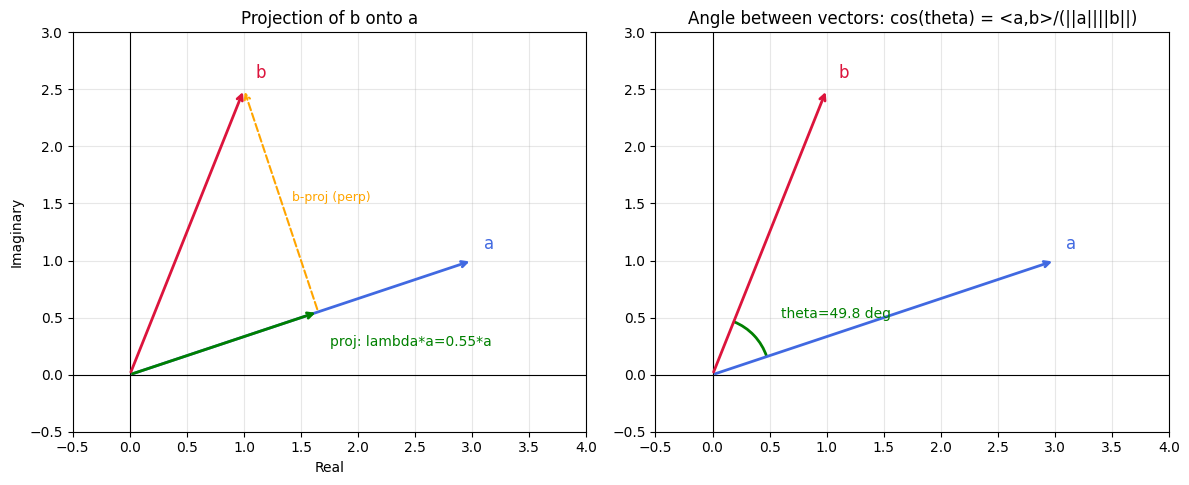

lambda = <a,b>/||a||^2 = 0.5500
Verify: <b-proj, a> = -4.44e-16  (should be 0)


In [5]:
# Visualize projection in 2D (as analog)
fig, axes = plt.subplots(1,2,figsize=(12,5))

# Left: projection
ax = axes[0]
a = np.array([3,1]); b = np.array([1,2.5])
lam = np.dot(a,b)/np.dot(a,a)
proj = lam*a
error = b - proj
ax.annotate('',xy=a,xytext=(0,0),arrowprops=dict(arrowstyle='->',color='royalblue',lw=2))
ax.annotate('',xy=b,xytext=(0,0),arrowprops=dict(arrowstyle='->',color='crimson',lw=2))
ax.annotate('',xy=proj,xytext=(0,0),arrowprops=dict(arrowstyle='->',color='green',lw=2))
ax.annotate('',xy=b,xytext=proj,arrowprops=dict(arrowstyle='->',color='orange',lw=1.5,ls='--'))
ax.text(a[0]+0.1,a[1]+0.1,'a',color='royalblue',fontsize=12)
ax.text(b[0]+0.1,b[1]+0.1,'b',color='crimson',fontsize=12)
ax.text(proj[0]+0.1,proj[1]-0.3,f'proj: lambda*a={lam:.2f}*a',color='green',fontsize=10)
ax.text((proj[0]+b[0])/2+0.1,(proj[1]+b[1])/2,'b-proj (perp)',color='orange',fontsize=9)
ax.axhline(0, color='k',lw=0.8); ax.axvline(0, color='k',lw=0.8)
ax.grid(True,alpha=0.3); ax.set_aspect('equal'); ax.set_xlim(-0.5,4); ax.set_ylim(-0.5,3)
ax.set_title('Projection of b onto a'); ax.set_xlabel('Real'); ax.set_ylabel('Imaginary')

# Right: angle between vectors
ax = axes[1]
vecs = [(a,'royalblue','a'),(b,'crimson','b')]
for v,col,lbl in vecs:
    ax.annotate('',xy=v,xytext=(0,0),arrowprops=dict(arrowstyle='->',color=col,lw=2))
    ax.text(v[0]+0.1,v[1]+0.1,lbl,color=col,fontsize=12)
cos_t = np.dot(a,b)/(np.linalg.norm(a)*np.linalg.norm(b))
angle = np.arccos(cos_t)
arc = plt.matplotlib.patches.Arc((0,0),1.0,1.0,angle=0,
    theta1=np.degrees(np.arctan2(a[1],a[0])),theta2=np.degrees(np.arctan2(b[1],b[0])),
    color='green',lw=2)
ax.add_patch(arc)
ax.text(0.6,0.5,f'theta={np.degrees(angle):.1f} deg',color='green',fontsize=10)
ax.axhline(0, color='k',lw=0.8); ax.axvline(0, color='k',lw=0.8)
ax.grid(True,alpha=0.3); ax.set_aspect('equal'); ax.set_xlim(-0.5,4); ax.set_ylim(-0.5,3)
ax.set_title(f'Angle between vectors: cos(theta) = <a,b>/(||a||||b||)')

plt.tight_layout(); plt.show()
print(f'lambda = <a,b>/||a||^2 = {lam:.4f}')
print(f'Verify: <b-proj, a> = {np.dot(b-proj,a):.2e}  (should be 0)')

---
### 8-11. Projection onto Range of a Matrix

Given $V = [v^{(1)}\cdots v^{(n)}]$ with **pairwise orthogonal columns**, the projection of $s$ onto $\mathcal{R}(V)$ minimizes $\|s-Vc\|$ and equals:
$$\hat{s} = Vc = \sum_{j=1}^n c_j v^{(j)}, \quad c_j = \frac{\langle v^{(j)}, s\rangle}{\|v^{(j)}\|^2}$$

The **error vector** $s-\hat{s}$ is orthogonal to every column of $V$.

If $n=m$ (square), then $\hat{s}=s$ (exact representation).

### 12. Example

$V = [v^{(1)}\, v^{(2)}]$ with $v^{(1)}=[1,-2,1]^T$, $v^{(2)}=[3,4,5]^T$:  
$\|v^{(1)}\|^2=6$, $\|v^{(2)}\|^2=50$. Orthogonal? $\langle v^{(1)},v^{(2)}\rangle = 3-8+5=0$. Yes!

Project $s=[-6,2,7]^T$ onto $\mathcal{R}(V)$:
$$c_1 = \frac{-6-4+7}{6} = -\tfrac{1}{2} \qquad c_2 = \frac{-18+8+35}{50} = \tfrac{1}{2}$$
$$\hat{s} = c_1 v^{(1)} + c_2 v^{(2)} = [1,3,2]^T$$


Checking orthogonality:
<v1,v2> = 0  (should be 0)
||v1||^2 = 6  ||v2||^2 = 50

c1 = <v1,s>/||v1||^2 = -3/6 = -0.5
c2 = <v2,s>/||v2||^2 = 25/50 = 0.5
s_hat = c1*v1 + c2*v2 = [1. 3. 2.]  (should be [1,3,2])
error = s - s_hat = [-7. -1.  5.]  (should be [-7,-1,5])
<error,v1> = 0.0  (should be 0)
<error,v2> = 0.0  (should be 0)


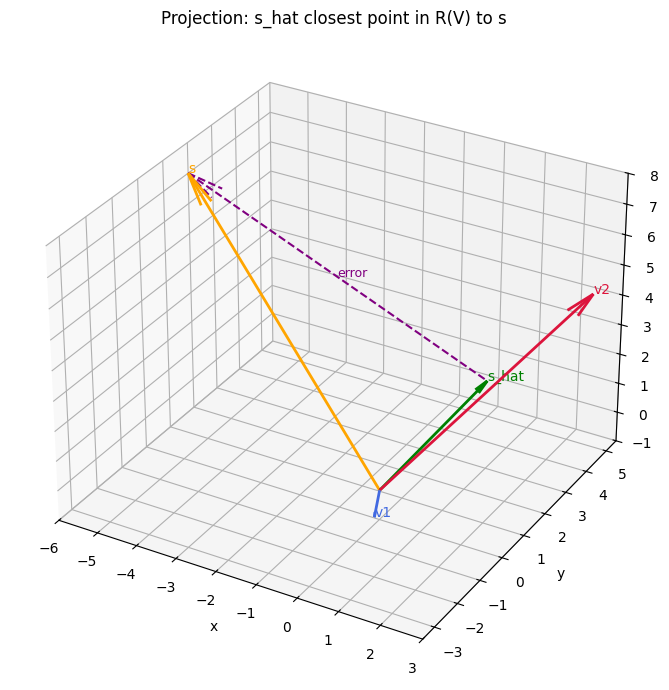

In [9]:
# Example 12: Projection onto range
v1 = np.array([1,-2,1])
v2 = np.array([3,4,5])
s  = np.array([-6,2,7])

print('Checking orthogonality:')
print(f'<v1,v2> = {v1@v2}  (should be 0)')
print(f'||v1||^2 = {v1@v1}  ||v2||^2 = {v2@v2}')

c1 = (v1@s)/(v1@v1)
c2 = (v2@s)/(v2@v2)
s_hat = c1*v1 + c2*v2
error = s - s_hat

print(f'\nc1 = <v1,s>/||v1||^2 = {v1@s}/{v1@v1} = {c1}')
print(f'c2 = <v2,s>/||v2||^2 = {v2@s}/{v2@v2} = {c2}')
print(f's_hat = c1*v1 + c2*v2 = {s_hat}  (should be [1,3,2])')
print(f'error = s - s_hat = {error}  (should be [-7,-1,5])')
print(f'<error,v1> = {error@v1}  (should be 0)')
print(f'<error,v2> = {error@v2}  (should be 0)')

# 3D visualization
fig = plt.figure(figsize=(8,7))
ax = fig.add_subplot(111, projection='3d')
origin = np.zeros(3)
for v, col, lbl in [(v1,'royalblue','v1'),(v2,'crimson','v2'),(s,'orange','s'),(s_hat,'green','s_hat')]:
    ax.quiver(*origin,*v,color=col,arrow_length_ratio=0.1,lw=2)
    ax.text(v[0],v[1],v[2],lbl,color=col,fontsize=10)
ax.quiver(*s_hat,*error,color='purple',arrow_length_ratio=0.1,lw=1.5,ls='--')
ax.text(*(s_hat+error/2),'error',color='purple',fontsize=9)
ax.set_xlabel('x'); ax.set_ylabel('y'); ax.set_zlabel('z')
ax.set_title('Projection: s_hat closest point in R(V) to s')

# Equal aspect ratio for 3D
X, Y, Z = zip(origin, v1, v2, s, s_hat, s_hat+error)
max_range = np.array([max(X)-min(X), max(Y)-min(Y), max(Z)-min(Z)]).max() / 2

mid_x = (max(X)+min(X)) * 0.5
mid_y = (max(Y)+min(Y)) * 0.5
mid_z = (max(Z)+min(Z)) * 0.5

ax.set_xlim(mid_x - max_range, mid_x + max_range)
ax.set_ylim(mid_y - max_range, mid_y + max_range)
ax.set_zlim(mid_z - max_range, mid_z + max_range)

plt.tight_layout(); plt.show()

---
## Summary

| Formula | Description |
|---|---|
| $\langle a,b\rangle = a^Tb$ | Inner product |
| $\|a\| = \sqrt{a^Ta}$ | Norm |
| $\cos\theta = \langle a,b\rangle/(\|a\|\|b\|)$ | Angle |
| $\lambda = \langle a,b\rangle/\|a\|^2$ | Projection coefficient |
| $c_j = \langle v^{(j)},s\rangle/\|v^{(j)}\|^2$ | Projection onto $\mathcal{R}(V)$ |

### Mistakes to Avoid
1. Projection formula $\lambda = \langle a,b\rangle/\|a\|^2$ — denominator is $\|a\|^2$, NOT $\|a\|$.
2. The error vector must be **orthogonal to every column of V**, not just perpendicular to $\hat{s}$.
3. Range $\mathcal{R}(V)$ only spans all of $\mathbb{R}^m$ when $n=m$ (square matrix). For $n<m$, projection gives the closest point, not the exact vector.
